In [3]:
import sys
import os
curr_dir=os.getcwd()
pardir=os.pardir
sys.path.append(os.path.join(curr_dir, pardir))
sys.path.append(os.path.join(curr_dir, pardir, pardir))
from liset_paper import liset_paper as liset_tk

import numpy as np
import matplotlib.pyplot as plt

from signal_aid import bandpass_filter
import matplotlib.pyplot as plt
# import seaborn as sns
from extract_Nripples.utils_encoding import *


In [4]:
parent=r"D:\neurospark_mat\Download_from_paper"
datasets=os.listdir(parent)
# print("Available datasets:")
# for i, dataset in enumerate(datasets):
#     print(f"{i}: {dataset}")
# print()
# dataset=int(input("Dataset to process: "))
dataset=3
dataset_path=os.path.join(parent,datasets[dataset])
print(f"Processing dataset: {datasets[dataset]}")

Processing dataset: Thy7-2020-11-11_16-05-00


In [5]:
liset=liset=liset_tk(dataset_path, shank=1, downsample=False, start=0, verbose=False)

ripples=liset.ripples_GT

In [6]:
channel=1
window=[5,10] # in seconds
print(ripples[:10])
mask = (ripples[:, 1] >= window[0]*liset.fs) & (ripples[:, 0] <= window[1]*liset.fs)
window_ripples = ripples[mask]
print(f"Ripples in window {window}: {len(window_ripples)}")
channel_data = liset.data[:, channel]

[[  4814   6045]
 [  9033  10000]
 [ 12959  14804]
 [ 23271  24882]
 [ 85127  86266]
 [ 86318  87695]
 [ 90537  92412]
 [ 97187  98681]
 [106591 108291]
 [125181 126483]]
Ripples in window [5, 10]: 13


In [7]:

# Process Data
filtered_channel = bandpass_filter(channel_data, fs=liset.fs, bandpass=(100,250), order=4)
threshold=calculate_threshold(filtered_channel[:120*liset.fs],liset.fs,0.1,0.25,1,plot=False,verbose=False)
print(f"Threshold: {threshold}")
up_down=up_down_channel(filtered_channel,threshold,liset.fs,refractory=0,initial_value=None,return_value=False)
spikes_downsample,spikes_lost=extract_spikes_downsample(up_down,30,)


Threshold: 0.3020455142004901


In [8]:
# Setup shared time window
start_idx = window[0] * liset.fs
end_idx = window[1] * liset.fs
time = np.arange(start_idx, end_idx) / liset.fs
filtered_data = filtered_channel[start_idx:end_idx]
up_down_window = up_down[start_idx:end_idx, :]
up_mask = up_down_window[:, 0] > 0
down_mask = up_down_window[:, 1] > 0
up_spike_times = time[up_mask]
down_spike_times = time[down_mask]
downsampled_start=int(start_idx/30)
downsampled_end=int(end_idx/30)
print(f"Downsampled start: {downsampled_start}, end: {downsampled_end}")
downsampled_time= np.arange(downsampled_start, downsampled_end)/1000

spikes_downsample_window = spikes_downsample[downsampled_start:downsampled_end,:]
ds_up_mask = spikes_downsample_window[:, 0] > 0
ds_down_mask = spikes_downsample_window[:, 1] > 0
ds_up_spike_times = downsampled_time[ds_up_mask]
ds_down_spike_times = downsampled_time[ds_down_mask]


Downsampled start: 5000, end: 10000


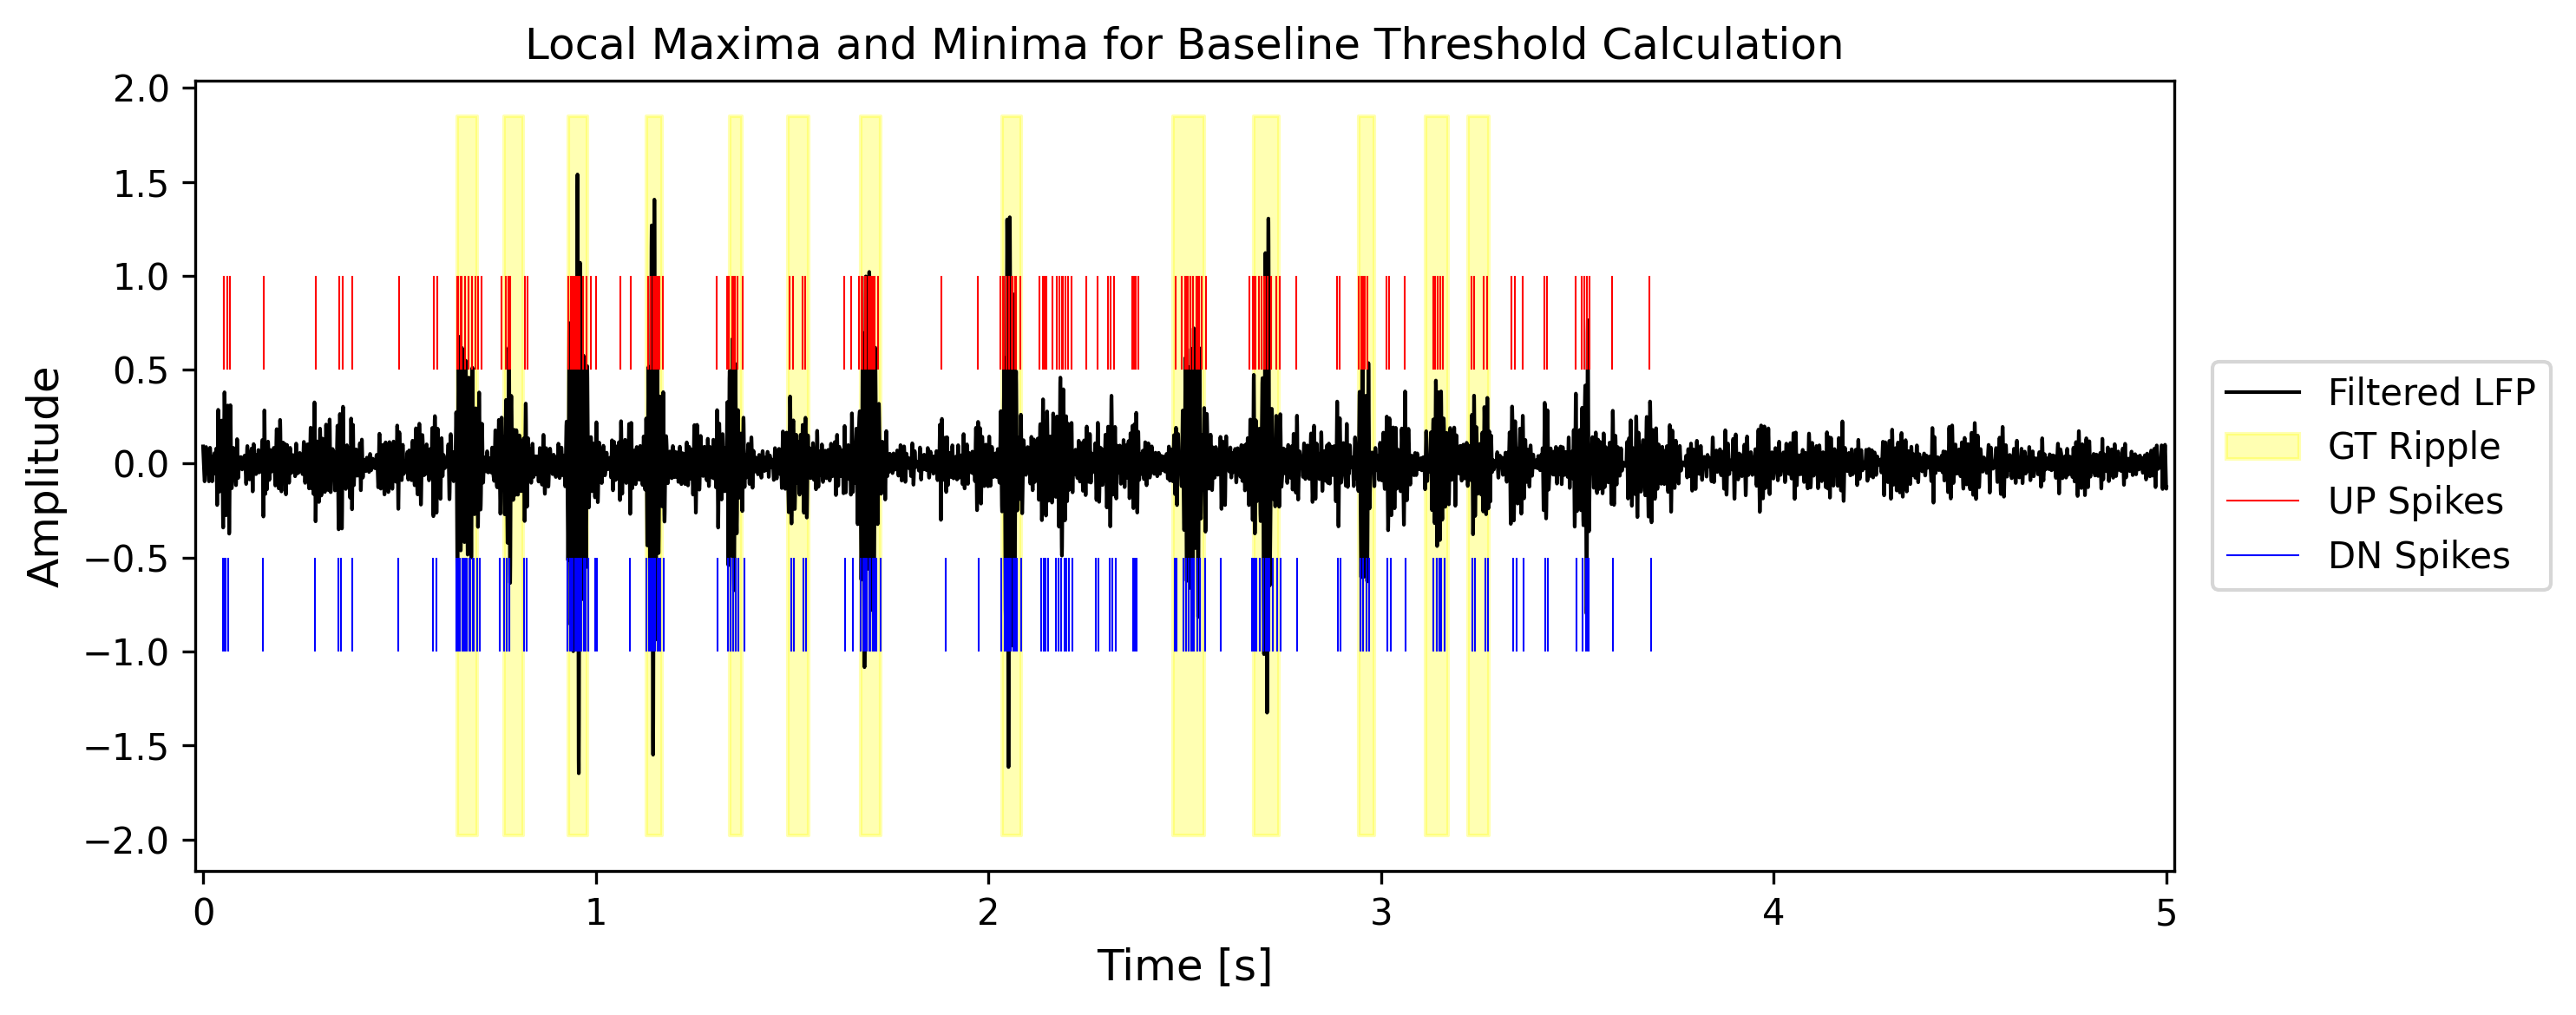

In [9]:
fig, ax = plt.subplots(figsize=(10, 4), dpi=300)

# Time axis starting from 0
time = np.arange(window[0]*liset.fs, window[1]*liset.fs) / liset.fs - window[0]

# Plot filtered data
min_data, max_data = np.min(filtered_data), np.max(filtered_data)
ax.plot(time, filtered_data, label="Filtered LFP", color='black', linewidth=1)

# Highlight ripples
for i, ripple in enumerate(window_ripples):
    start, end = ripple / liset.fs - window[0]
    ax.fill_between([start, end],
                    min_data * 1.2, max_data * 1.2,
                    color="yellow", alpha=0.3,
                    label=f"GT Ripple" if i == 0 else None)

ax.vlines(ds_up_spike_times-window[0], ymin=0.5, ymax=1, color='red', linewidth=0.5,label="UP Spikes")
ax.vlines(ds_down_spike_times-window[0], ymin=-1, ymax=-0.5, color='blue', linewidth=0.5,label="DN Spikes")

# Final plot formatting
ax.set_xlabel("Time [s]",fontsize=12)
ax.set_ylabel("Amplitude",fontsize=12)
ax.set_title("Local Maxima and Minima for Baseline Threshold Calculation")
# ax.set_xticks(np.arange(0, window[1] - window[0] + 0.1, 0.1))
# ax.set_yticks(np.arange(min_data * 1.2, max_data * 1.2, (max_data - min_data) / 5))
ax.set_xlim(-0.02, window[1] - window[0]+0.02)
# ax.set_yticks([-2,-1, 0, 1, 2])
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5))
plt.tight_layout()


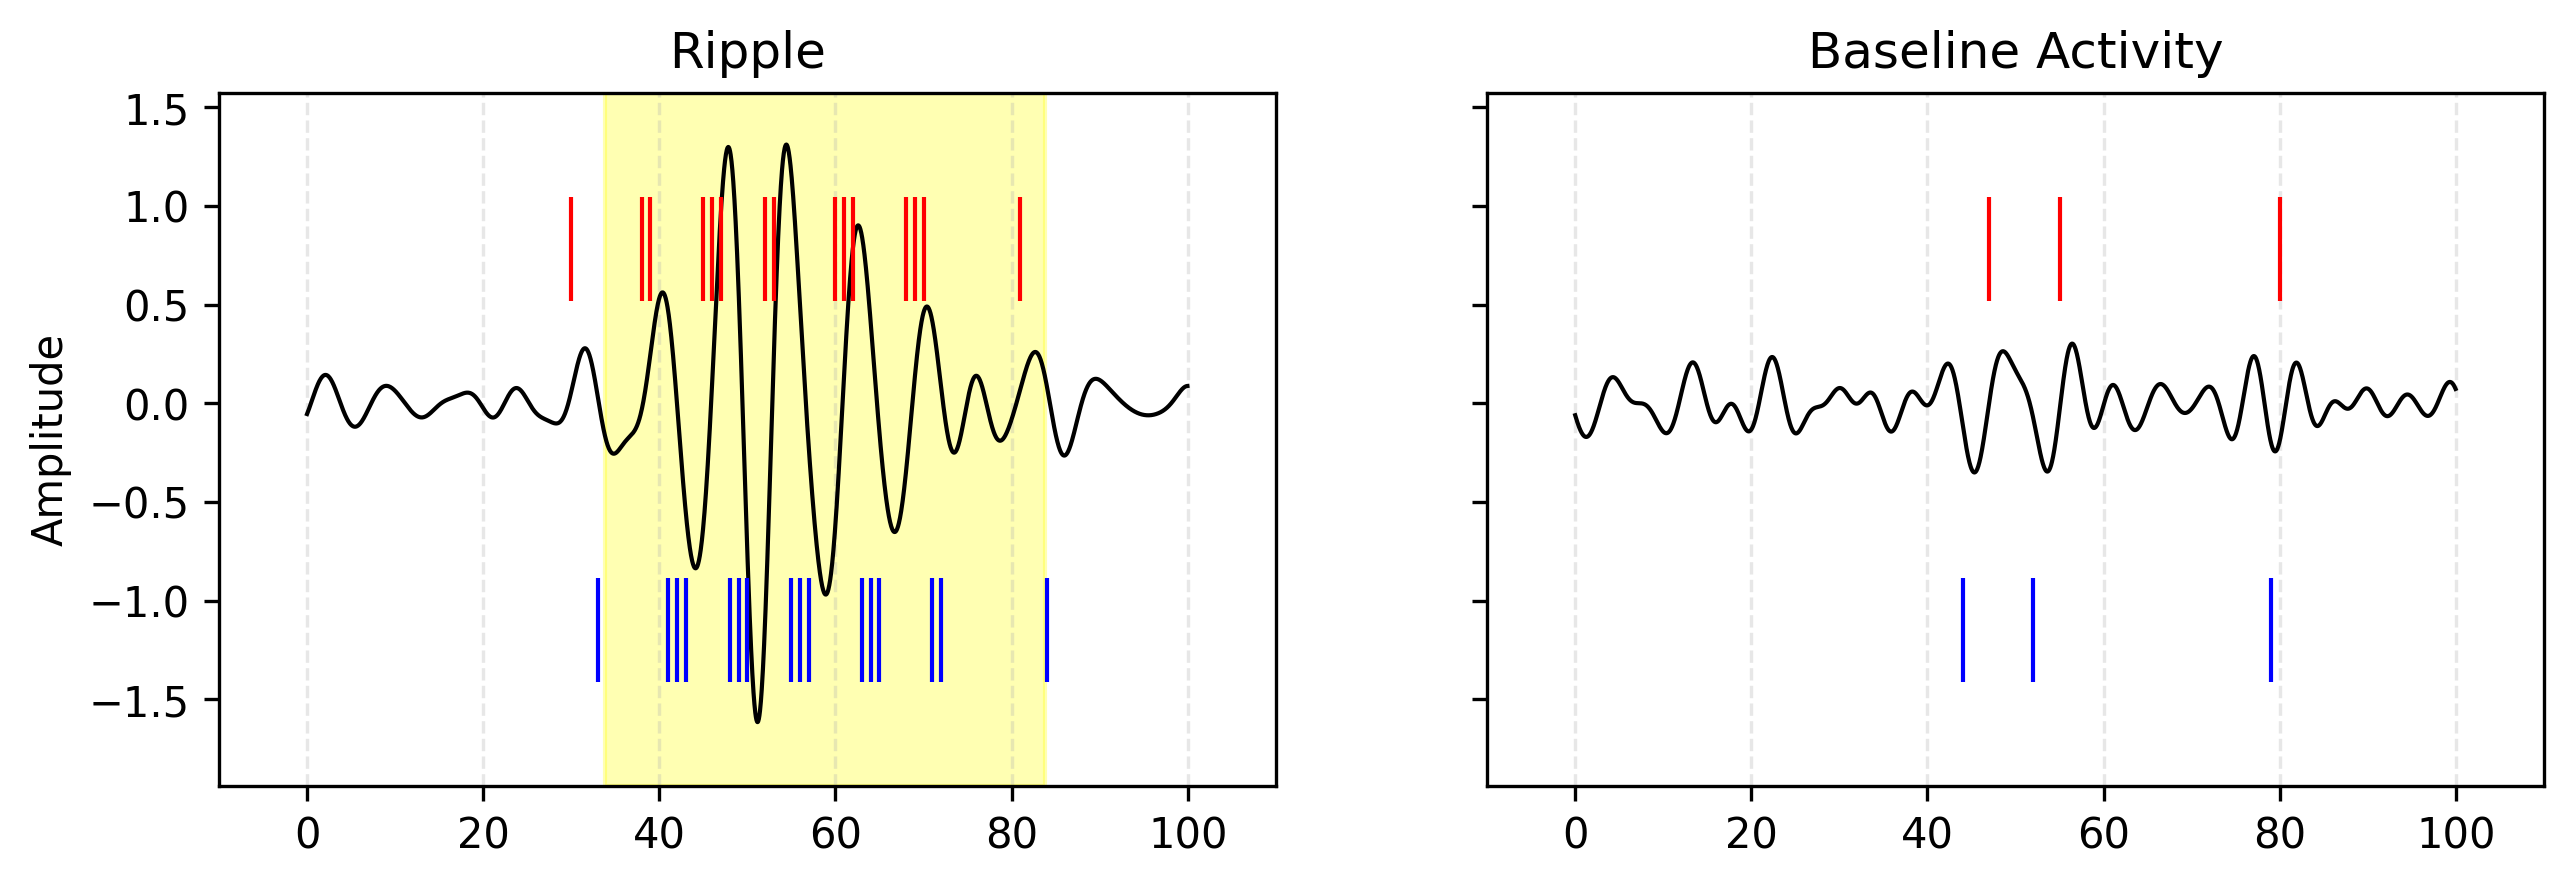

In [10]:
from collections import OrderedDict


# Define two smaller time windows relative to `window`
sub_windows = [[2, 2.1], [0.3, 0.4]]
titles = ["Ripple", "Baseline Activity"]

# Create subplot: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(10, 3), dpi=300, sharey=True)

for idx, sub_win in enumerate(sub_windows):
    ax = axes[idx]

    # Convert subwindow time range to indices
    start_idx = int((sub_win[0] + window[0]) * liset.fs)
    end_idx = int((sub_win[1] + window[0]) * liset.fs)

    # Get absolute time bounds
    sub_start_time = sub_win[0] + window[0]
    sub_end_time = sub_win[1] + window[0]

    # Time vector for full sampling rate (in ms)
    time = (np.arange(start_idx, end_idx) / liset.fs - sub_start_time) * 1000
    
    # Extract filtered LFP data
    sub_filtered = filtered_channel[start_idx:end_idx]
    min_data, max_data = np.min(sub_filtered), np.max(sub_filtered)
    
    # 30kHz spikes
    up_down_window = up_down[start_idx:end_idx, :]
    up_mask = up_down_window[:, 0] > 0
    down_mask = up_down_window[:, 1] > 0
    up_spike_times = time[up_mask]
    down_spike_times = time[down_mask]
    
    # 1kHz downsampled spikes
    down_start = int(start_idx / 30)
    down_end = int(end_idx / 30)
    down_time = (np.arange(down_start, down_end) / 1000 - sub_start_time) * 1000
    ds_window = spikes_downsample[down_start:down_end, :]
    ds_up_mask = ds_window[:, 0] > 0
    ds_down_mask = ds_window[:, 1] > 0
    ds_up_times = down_time[ds_up_mask]
    ds_down_times = down_time[ds_down_mask]
    
    if "y_min" not in locals():
        y_min = min_data * 1.2
        y_max = max_data * 1.2
    # Plot LFP
    ax.plot(time, sub_filtered, color='black', linewidth=1)
    
    # Plot spikes
    spike_height = (y_max - y_min) * 0.15

    # Plot UP spikes in upper band
    ax.vlines(ds_up_times,
            ymin=y_max - spike_height*2,
            ymax=y_max-spike_height,
            color='red', linewidth=1, label="UP Spikes")

    # Plot DOWN spikes in lower band
    ax.vlines(ds_down_times,
            ymin=y_min+spike_height,
            ymax=y_min + spike_height*2,
            color='blue', linewidth=1, label="DN Spikes")

    # Plot GT ripples (assuming `window_ripples` is in samples from the start of the recording)
    for i, ripple in enumerate(window_ripples):
        ripple_start_time = ripple[0] / liset.fs
        ripple_end_time = ripple[1] / liset.fs
        if ripple_end_time >= sub_start_time and ripple_start_time <= sub_end_time:
            rel_start = (ripple_start_time - sub_start_time) * 1000
            rel_end = (ripple_end_time - sub_start_time) * 1000
            ax.fill_between(
                [rel_start, rel_end],
                y_min, y_max,
                color='yellow', alpha=0.3,
                label="GT Ripple" if idx == 0 else None
            )
    
    # Formatting
    ax.grid(True, linestyle='--', alpha=0.3,which="major",axis="x")
    ax.set_title(titles[idx])
    if idx == 0:
        ax.set_ylabel("Amplitude")
    ax.set_xlim(-10, (sub_win[1] - sub_win[0]) * 1000 + 10)  # ±10 ms margin
    ax.set_ylim(y_min, y_max)
    # ax.grid(True, linestyle='--', alpha=0.5)
# === Shared X-axis label ===
# fig.supxlabel("Time [ms]", fontsize=12)

# === Shared Legend ===
handles_labels = [ax.get_legend_handles_labels() for ax in axes]
handles = sum([hl[0] for hl in handles_labels], [])
labels = sum([hl[1] for hl in handles_labels], [])
unique = list(OrderedDict.fromkeys(zip(labels, handles)))
labels, handles = zip(*unique)
# # Plot shared legend
# fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.01, 0.5),
#            frameon=True, borderpad=1, edgecolor="gray", fontsize=12)

# === Adjust Layout ===
# fig.subplots_adjust(left=0.07, right=0.95, bottom=0.2, wspace=0.07)
# fig.subplots_adjust(left=0.07, right=0.95, bottom=0.2, wspace=0.07)

plt.show()

fig_path= os.path.join(os.getcwd(),"pngs", "spike_encoding.png")
fig.savefig(fig_path, bbox_inches='tight', dpi=300)

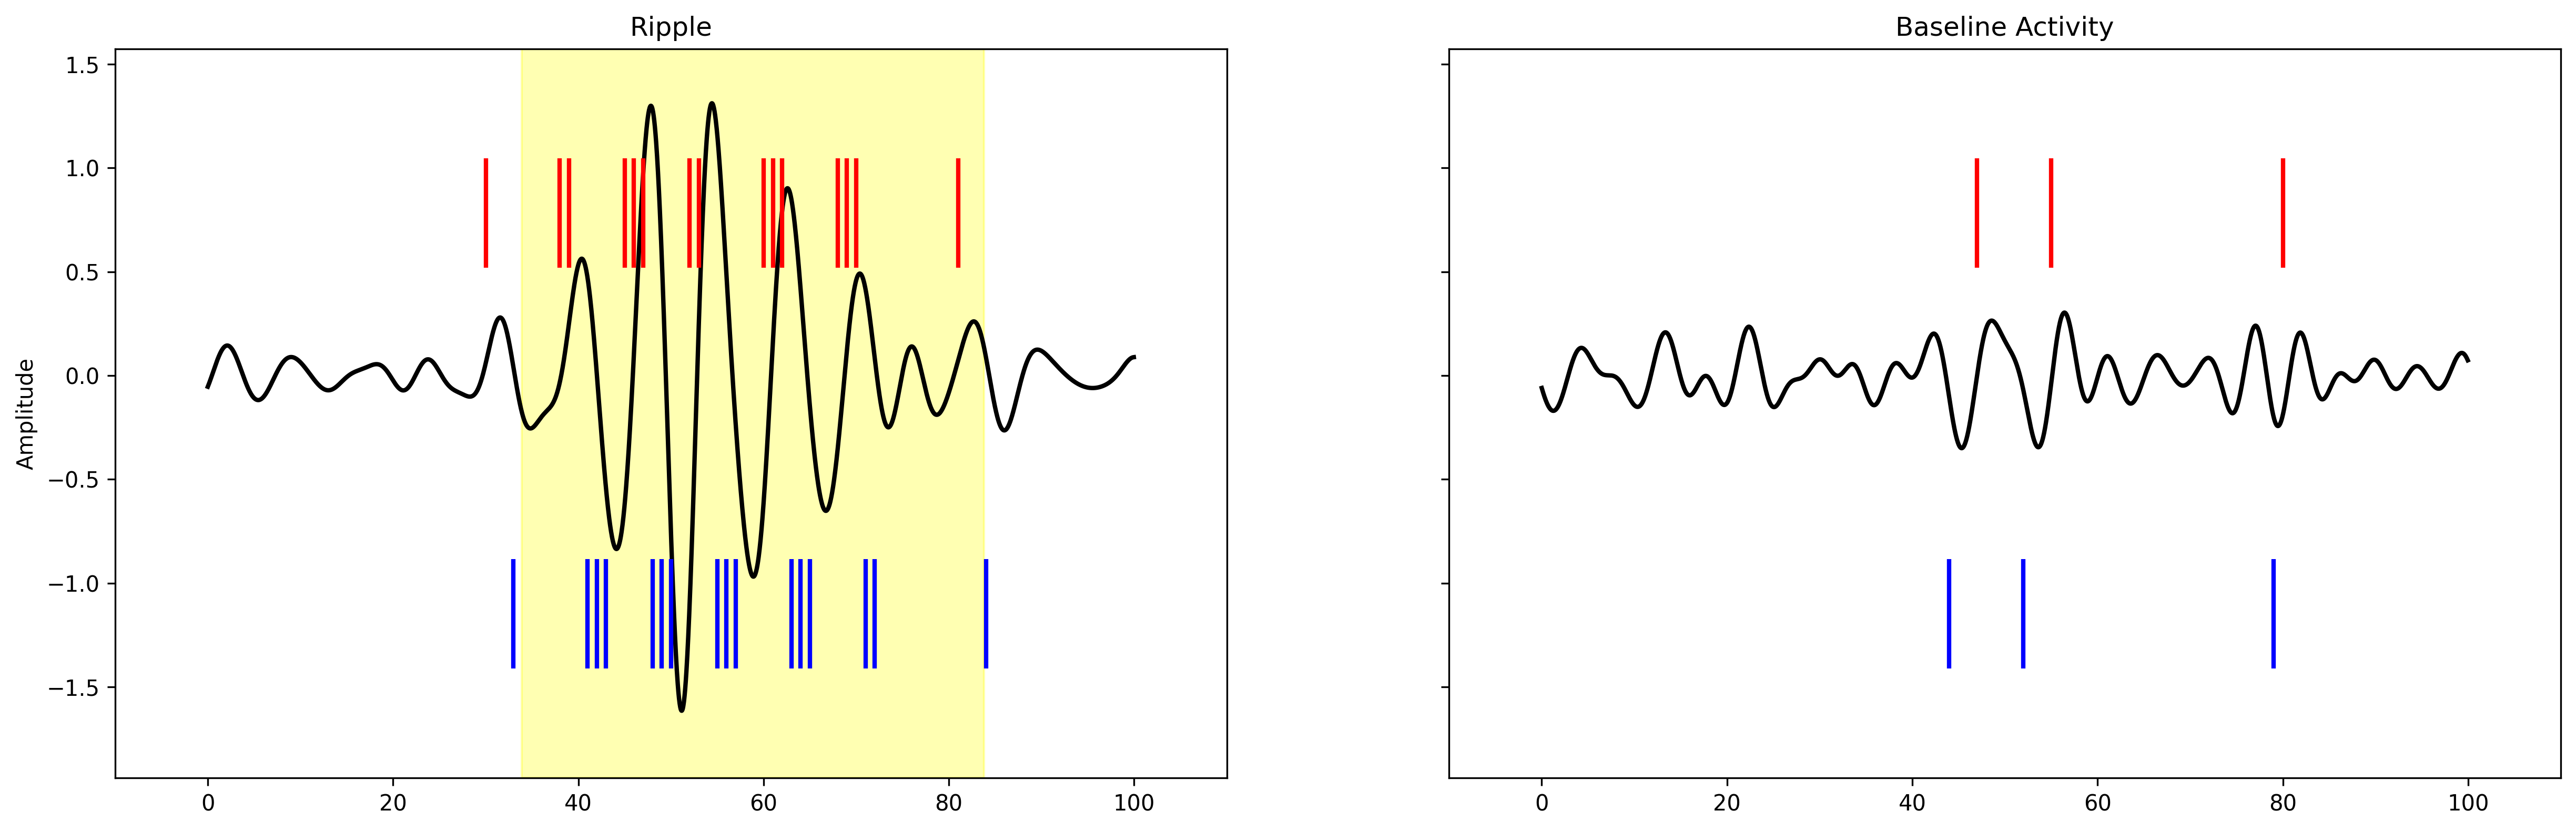

In [14]:
from collections import OrderedDict


# Define two smaller time windows relative to `window`
sub_windows = [[2, 2.1], [0.3, 0.4]]
titles = ["Ripple", "Baseline Activity"]

# Create subplot: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(20, 6), dpi=300, sharey=True)

for idx, sub_win in enumerate(sub_windows):
    ax = axes[idx]

    # Convert subwindow time range to indices
    start_idx = int((sub_win[0] + window[0]) * liset.fs)
    end_idx = int((sub_win[1] + window[0]) * liset.fs)

    # Get absolute time bounds
    sub_start_time = sub_win[0] + window[0]
    sub_end_time = sub_win[1] + window[0]

    # Time vector for full sampling rate (in ms)
    time = (np.arange(start_idx, end_idx) / liset.fs - sub_start_time) * 1000
    
    # Extract filtered LFP data
    sub_filtered = filtered_channel[start_idx:end_idx]
    min_data, max_data = np.min(sub_filtered), np.max(sub_filtered)
    
    # 30kHz spikes
    up_down_window = up_down[start_idx:end_idx, :]
    up_mask = up_down_window[:, 0] > 0
    down_mask = up_down_window[:, 1] > 0
    up_spike_times = time[up_mask]
    down_spike_times = time[down_mask]
    
    # 1kHz downsampled spikes
    down_start = int(start_idx / 30)
    down_end = int(end_idx / 30)
    down_time = (np.arange(down_start, down_end) / 1000 - sub_start_time) * 1000
    ds_window = spikes_downsample[down_start:down_end, :]
    ds_up_mask = ds_window[:, 0] > 0
    ds_down_mask = ds_window[:, 1] > 0
    ds_up_times = down_time[ds_up_mask]
    ds_down_times = down_time[ds_down_mask]
    
    if "y_min" not in locals():
        y_min = min_data * 1.2
        y_max = max_data * 1.2
    # Plot LFP
    ax.plot(time, sub_filtered, color='black', linewidth=2)
    
    # Plot spikes
    spike_height = (y_max - y_min) * 0.15

    # Plot UP spikes in upper band
    ax.vlines(ds_up_times,
            ymin=y_max - spike_height*2,
            ymax=y_max-spike_height,
            color='red', linewidth=2, label="UP Spikes")

    # Plot DOWN spikes in lower band
    ax.vlines(ds_down_times,
            ymin=y_min+spike_height,
            ymax=y_min + spike_height*2,
            color='blue', linewidth=2, label="DN Spikes")

    # Plot GT ripples (assuming `window_ripples` is in samples from the start of the recording)
    for i, ripple in enumerate(window_ripples):
        ripple_start_time = ripple[0] / liset.fs
        ripple_end_time = ripple[1] / liset.fs
        if ripple_end_time >= sub_start_time and ripple_start_time <= sub_end_time:
            rel_start = (ripple_start_time - sub_start_time) * 1000
            rel_end = (ripple_end_time - sub_start_time) * 1000
            ax.fill_between(
                [rel_start, rel_end],
                y_min, y_max,
                color='yellow', alpha=0.3,
                label="GT Ripple" if idx == 0 else None
            )
    
    # Formatting
    ax.grid(False,)
    ax.set_title(titles[idx])
    if idx == 0:
        ax.set_ylabel("Amplitude")
    ax.set_xlim(-10, (sub_win[1] - sub_win[0]) * 1000 + 10)  # ±10 ms margin
    ax.set_ylim(y_min, y_max)
    # ax.grid(True, linestyle='--', alpha=0.5)
# === Shared X-axis label ===
# fig.supxlabel("Time [ms]", fontsize=12)

# === Shared Legend ===
handles_labels = [ax.get_legend_handles_labels() for ax in axes]
handles = sum([hl[0] for hl in handles_labels], [])
labels = sum([hl[1] for hl in handles_labels], [])
unique = list(OrderedDict.fromkeys(zip(labels, handles)))
labels, handles = zip(*unique)
# # Plot shared legend
# fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.01, 0.5),
#            frameon=True, borderpad=1, edgecolor="gray", fontsize=12)

# === Adjust Layout ===
# fig.subplots_adjust(left=0.07, right=0.95, bottom=0.2, wspace=0.07)
# fig.subplots_adjust(left=0.07, right=0.95, bottom=0.2, wspace=0.07)

plt.show()

fig_path= os.path.join(os.getcwd(),"pngs", "spike_encoding_ripple.png")
fig.savefig(fig_path, bbox_inches='tight', dpi=300)

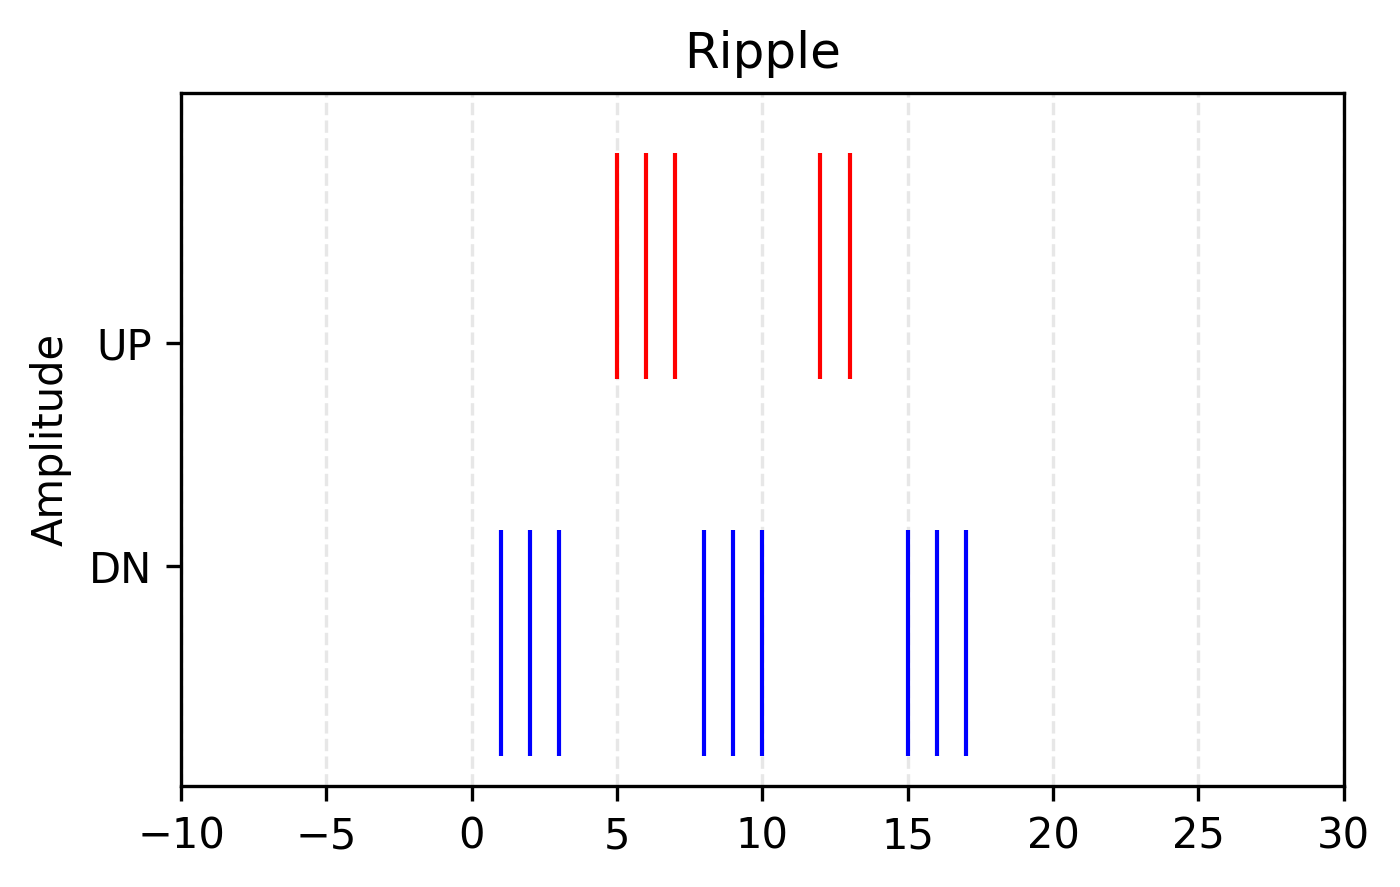

In [19]:
from collections import OrderedDict


# Define two smaller time windows relative to `window`
window_size=0.02
start=2.04
sub_windows = [start,start+window_size]
title = ["Buffer"]

# Create subplot: 1 row, 2 columns
fig, axes = plt.subplots( figsize=(5,3), dpi=300, sharey=True)
axes=[axes]
ax = axes[idx]

# Convert subwindow time range to indices
start_idx = int((sub_windows[0] + window[0]) * liset.fs)
end_idx = int((sub_windows[1] + window[0]) * liset.fs)

# Get absolute time bounds
sub_start_time = sub_windows[0] + window[0]
sub_end_time = sub_windows[1] + window[0]

# Time vector for full sampling rate (in ms)
time = (np.arange(start_idx, end_idx) / liset.fs - sub_start_time) * 1000

# Extract filtered LFP data
sub_filtered = filtered_channel[start_idx:end_idx]
min_data, max_data = np.min(sub_filtered), np.max(sub_filtered)

# 30kHz spikes
up_down_window = up_down[start_idx:end_idx, :]
up_mask = up_down_window[:, 0] > 0
down_mask = up_down_window[:, 1] > 0
up_spike_times = time[up_mask]
down_spike_times = time[down_mask]

# 1kHz downsampled spikes
down_start = int(start_idx / 30)
down_end = int(end_idx / 30)
down_time = (np.arange(down_start, down_end) / 1000 - sub_start_time) * 1000
ds_window = spikes_downsample[down_start:down_end, :]
ds_up_mask = ds_window[:, 0] > 0
ds_down_mask = ds_window[:, 1] > 0
ds_up_times = down_time[ds_up_mask]
ds_down_times = down_time[ds_down_mask]

if "y_min" not in locals():
    y_min = min_data * 1.2
    y_max = max_data * 1.2
# Plot LFP
# ax.plot(time, sub_filtered, color='black', linewidth=1)

# Plot spikes
spike_height = (y_max - y_min) * 0.2

# Plot UP spikes in upper band
ax.vlines(ds_up_times,
        ymin=0.25,
        ymax=1,
        color='red', linewidth=1, label="UP Spikes")

# Plot DOWN spikes in lower band
ax.vlines(ds_down_times,
        ymin=-1,
        ymax=-0.25,
        color='blue', linewidth=1, label="DN Spikes")

# # Plot GT ripples (assuming `window_ripples` is in samples from the start of the recording)
# for i, ripple in enumerate(window_ripples):
#     ripple_start_time = ripple[0] / liset.fs
#     ripple_end_time = ripple[1] / liset.fs
#     if ripple_end_time >= sub_start_time and ripple_start_time <= sub_end_time:
#         rel_start = (ripple_start_time - sub_start_time) * 1000
#         rel_end = (ripple_end_time - sub_start_time) * 1000
#         ax.fill_between(
#             [rel_start, rel_end],
#             y_min, y_max,
#             color='yellow', alpha=0.3,
#             label="GT Ripple" if idx == 0 else None
#         )

# Formatting
ax.grid(True, linestyle='--', alpha=0.3,which="major",axis="x")
ax.set_title(titles[idx])
if idx == 0:
    ax.set_ylabel("Amplitude")
ax.set_xlim(-10, (sub_windows[1] - sub_windows[0]) * 1000 + 10)  # ±10 ms margin
ax.set_ylim(-1.1,1.2)
ax.set_yticks([-0.37,0.37])
ax.set_yticklabels(["DN","UP"])
    # ax.grid(True, linestyle='--', alpha=0.5)
# === Shared X-axis label ===
# fig.supxlabel("Time [ms]", fontsize=12)

# === Shared Legend ===
handles_labels = [ax.get_legend_handles_labels() for ax in axes]
handles = sum([hl[0] for hl in handles_labels], [])
labels = sum([hl[1] for hl in handles_labels], [])
unique = list(OrderedDict.fromkeys(zip(labels, handles)))
labels, handles = zip(*unique)
# # Plot shared legend
# fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.01, 0.5),
#            frameon=True, borderpad=1, edgecolor="gray", fontsize=12)

# === Adjust Layout ===
# fig.subplots_adjust(left=0.07, right=0.95, bottom=0.2, wspace=0.07)
# fig.subplots_adjust(left=0.07, right=0.95, bottom=0.2, wspace=0.07)

plt.show()

fig_path= os.path.join(os.getcwd(),"pngs", "spike_encoding.png")
fig.savefig(fig_path, bbox_inches='tight', dpi=300)